<a href="https://colab.research.google.com/github/lovita11/DataScience/blob/main/Pertemuan12_LovitaPrasetiaLestari_250401020061.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Nama : Lovita Prasetia Lestari

NIM : 250401020061

Kelas : IF403

In [15]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd, numpy as np
import matplotlib.pyplot as plt

Contoh transaksi:
[[np.str_('Keju'), np.str_('Roti'), np.str_('Mentega'), np.str_('Kopi'), 'Selai'], [np.str_('Roti'), np.str_('Kopi'), np.str_('Teh'), np.str_('Selai'), np.str_('Mentega')], [np.str_('Kopi'), np.str_('Susu'), np.str_('Teh')]]
Jumlah transaksi : 50


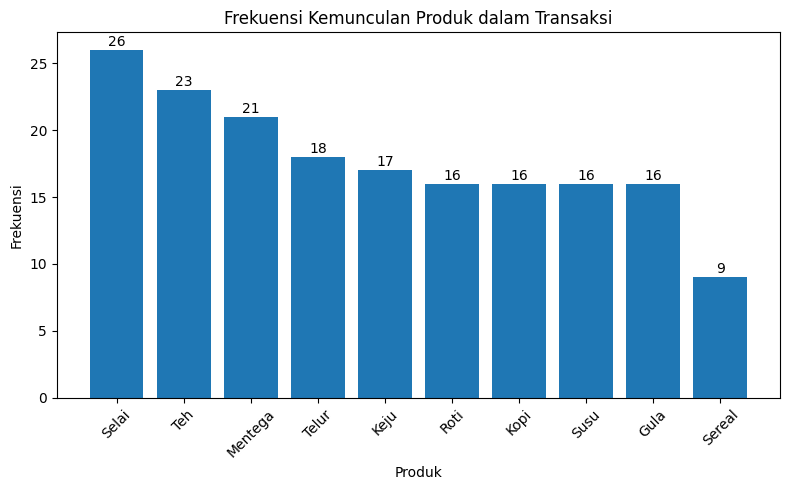

In [36]:
# ==================================================
# Langkah 1: Generate & Eksplorasi Dataset Transaksi
# ==================================================

np.random.seed(42)

produk = ['Roti', 'Selai', 'Susu', 'Sereal', 'Telur',
         'Keju', 'Kopi', 'Gula', 'Teh', 'Mentega']

# Buat 50 transaksi, tiap transaksi berisi 2-5 produk
transaksi = []

for _ in range(50):
    n_item = np.random.randint(2, 6)
    transaksi.append(list(np.random.choice(produk, n_item, replace=False)))

# Suntikkan pola: Roti sering bersama Selai
for i in range(20):
    if 'Roti' in transaksi[i] and 'Selai' not in transaksi[i]:
        transaksi[i].append('Selai')

print("Contoh transaksi:")
print(transaksi[:3])

print("Jumlah transaksi :", len(transaksi))

plt.figure(figsize=(8,5))

bars = plt.bar(df_frekuensi['Produk'], df_frekuensi['Frekuensi'])

plt.xlabel('Produk')
plt.ylabel('Frekuensi')
plt.title('Frekuensi Kemunculan Produk dalam Transaksi')
plt.xticks(rotation=45)

for bar in bars:
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 0.3,
        int(bar.get_height()),
        ha='center'
    )

plt.tight_layout()
plt.show()

In [37]:
from collections import Counter

semua_produk = [item for transaksi_item in transaksi for item in transaksi_item]

frekuensi = Counter(semua_produk)

df_frekuensi = pd.DataFrame(
    frekuensi.items(),
    columns=['Produk', 'Frekuensi']
).sort_values('Frekuensi', ascending=False)

print(df_frekuensi)

    Produk  Frekuensi
4    Selai         26
5      Teh         23
2  Mentega         21
7    Telur         18
0     Keju         17
1     Roti         16
3     Kopi         16
6     Susu         16
8     Gula         16
9   Sereal          9


In [39]:
# =====================================
# Langkah 2: One-Hot Encoding Transaksi
# =====================================

from mlxtend.preprocessing import TransactionEncoder

te = TransactionEncoder()
te_array = te.fit(transaksi).transform(transaksi)

df = pd.DataFrame(te_array, columns=te.columns_)

print(df.head())

    Gula   Keju   Kopi  Mentega   Roti  Selai  Sereal   Susu    Teh  Telur
0  False   True   True     True   True   True   False  False  False  False
1  False  False   True     True   True   True   False  False   True  False
2  False  False   True    False  False  False   False   True   True  False
3  False   True  False    False  False   True   False  False   True   True
4   True   True  False     True  False  False   False   True  False  False


In [40]:
# ===============================================
# Langkah 3: Cari Frequent Itemset dengan Apriori
# ===============================================

from mlxtend.frequent_patterns import apriori

for ms in [0.05, 0.1, 0.2]:
    freq = apriori(df, min_support=ms, use_colnames=True)
    print(f"min_support={ms}: {len(freq)} itemset ditemukan")

# Gunakan min_support 0.1 untuk analisis berikutnya
freq_items = apriori(df, min_support=0.1, use_colnames=True)

freq_items = freq_items.sort_values(
    'support',
    ascending=False
)

print(freq_items.head(10))

min_support=0.05: 74 itemset ditemukan
min_support=0.1: 44 itemset ditemukan
min_support=0.2: 13 itemset ditemukan
    support      itemsets
5      0.52       (Selai)
8      0.46         (Teh)
3      0.42     (Mentega)
9      0.36       (Telur)
1      0.34        (Keju)
0      0.32        (Gula)
2      0.32        (Kopi)
4      0.32        (Roti)
7      0.32        (Susu)
36     0.24  (Teh, Selai)


         antecedents consequents  support  confidence      lift
8        (Keju, Teh)     (Telur)     0.12    0.857143  2.380952
14  (Mentega, Selai)      (Kopi)     0.10    0.625000  1.953125
11      (Roti, Gula)     (Selai)     0.10    1.000000  1.923077
7           (Sereal)   (Mentega)     0.14    0.777778  1.851852
10      (Teh, Telur)      (Keju)     0.12    0.600000  1.764706
13     (Kopi, Selai)   (Mentega)     0.10    0.714286  1.700680
9      (Keju, Telur)       (Teh)     0.12    0.750000  1.630435
12     (Gula, Selai)      (Roti)     0.10    0.500000  1.562500
15   (Kopi, Mentega)     (Selai)     0.10    0.714286  1.373626
1             (Roti)     (Selai)     0.22    0.687500  1.322115


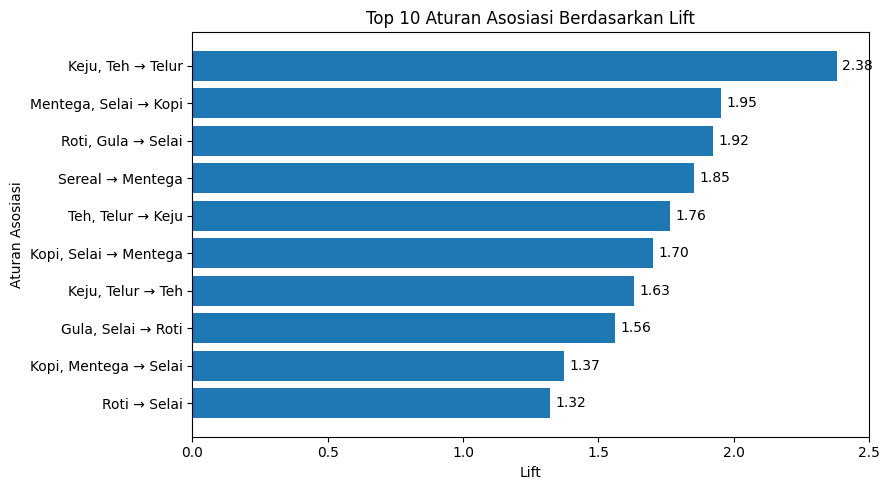

In [42]:
# ===============================================
# Langkah 4: Bentuk & Saring Aturan Asosiasi
# ===============================================
from mlxtend.frequent_patterns import association_rules

rules = association_rules(
    freq_items,
    metric='confidence',
    min_threshold=0.5
)

rules = rules[rules['lift'] > 1].sort_values(
    'lift',
    ascending=False
)

print(rules[[
    'antecedents',
    'consequents',
    'support',
    'confidence',
    'lift'
]].head(10))

top_rules = rules.head(10).copy()

top_rules['Aturan'] = (
    top_rules['antecedents'].apply(lambda x: ', '.join(list(x)))
    + ' → ' +
    top_rules['consequents'].apply(lambda x: ', '.join(list(x)))
)

plt.figure(figsize=(9,5))
bars = plt.barh(top_rules['Aturan'], top_rules['lift'])

plt.xlabel('Lift')
plt.ylabel('Aturan Asosiasi')
plt.title('Top 10 Aturan Asosiasi Berdasarkan Lift')
plt.gca().invert_yaxis()

for bar in bars:
    plt.text(
        bar.get_width() + 0.02,
        bar.get_y() + bar.get_height()/2,
        f'{bar.get_width():.2f}',
        va='center'
    )

plt.tight_layout()
plt.show()

In [51]:
# ==============================================================
# Langkah 5: Rekomender Sederhana dengan Content-Based Filtering
# ==============================================================

from sklearn.metrics.pairwise import cosine_similarity

katalog = pd.DataFrame({
    'produk': produk,
    'kategori': [
        'Bakery', 'Bakery', 'Dairy', 'Bakery', 'Dairy',
        'Dairy', 'Minuman', 'Bumbu', 'Minuman', 'Dairy'
    ]
})

fitur = pd.get_dummies(katalog['kategori'])
sim_matrix = cosine_similarity(fitur)

print(katalog)

    produk kategori
0     Roti   Bakery
1    Selai   Bakery
2     Susu    Dairy
3   Sereal   Bakery
4    Telur    Dairy
5     Keju    Dairy
6     Kopi  Minuman
7     Gula    Bumbu
8      Teh  Minuman
9  Mentega    Dairy


In [60]:
# ======================================
# Langkah 6: Bandingkan Kedua Pendekatan
# ======================================
def rekomendasi_serupa(nama_produk, top_n=3):
    idx = katalog.index[katalog['produk'] == nama_produk][0]

    skor = list(enumerate(sim_matrix[idx]))
    skor = sorted(skor, key=lambda x: x[1], reverse=True)

    skor = [s for s in skor if s[0] != idx][:top_n]

    return katalog.iloc[[i for i, _ in skor]]['produk'].tolist()

print("Mirip dengan Roti:", rekomendasi_serupa("Roti"))
product_target = 'Roti'

# Dari association rules: cari consequents dari aturan
# yang antecedent-nya mengandung product_target
rules_target = rules[
    rules['antecedents'].apply(lambda x: product_target in x)
]

print('Rekomendasi dari Association Rules:')
print(rules_target[['consequents', 'lift']].head())

print('\nRekomendasi dari Content-Based:')
print(rekomendasi_serupa(product_target))


Mirip dengan Roti: ['Selai', 'Sereal', 'Susu']
Rekomendasi dari Association Rules:
   consequents      lift
11     (Selai)  1.923077
1      (Selai)  1.322115

Rekomendasi dari Content-Based:
['Selai', 'Sereal', 'Susu']


Kesimpulan:
Berdasarkan praktikum Pertemuan 12, dapat disimpulkan bahwa Association Rules menggunakan algoritma Apriori mampu menemukan pola keterkaitan produk berdasarkan transaksi pelanggan. Hasil analisis menunjukkan adanya hubungan positif antarproduk, salah satunya Roti dan Selai, yang ditunjukkan oleh nilai lift lebih dari 1. Semakin tinggi nilai lift, semakin kuat hubungan antarproduk tersebut.

Content-Based Filtering menghasilkan rekomendasi berdasarkan kesamaan karakteristik atau kategori produk, bukan berdasarkan pola pembelian pelanggan. Perbedaan cara kerja:
Association Rules memanfaatkan pola transaksi.
Content-Based Filtering memanfaatkan kemiripan produk.

Kombinasi kedua pendekatan dapat digunakan untuk membangun sistem rekomendasi yang lebih relevan dan membantu menentukan produk yang tepat untuk direkomendasikan kepada pelanggan.